# CelebA: CNN Architecture, Training, and Objective Comparison

This notebook compares **CNN architecture and training choices** for CelebA face-attribute classification. The focus is not classical-vs-neural classification; instead, it evaluates how CNN depth, pooling, batch size, normalization, augmentation, API design, and output/loss formulation affect binary and multi-label attribute prediction.

### Main comparisons
- Four convolutional blocks vs five blocks
- Default learning rate vs higher initial learning rate
- Different batch sizes
- Max pooling vs average pooling
- Without vs with batch normalization
- Without vs with image augmentation
- Sequential API vs Functional API
- Softmax vs sigmoid outputs
- Categorical cross-entropy vs binary cross-entropy for multi-label prediction

### Experiments
- Single binary attribute classification with VGG-style CNNs
- Network depth comparisons
- Learning-rate scheduling
- Batch-size comparisons
- Max pooling vs average pooling
- Batch normalization on/off
- Image augmentation
- Functional API binary classifier
- Multi-attribute target encodings
- Softmax objective experiments
- Final sigmoid + binary cross-entropy multi-label formulation

CelebA is not bundled with this repository. See `data/README.md` for the expected files.

## 1. Setup

In [5]:
from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Conv2D, MaxPooling2D,
    AveragePooling2D, BatchNormalization, Dropout,
)
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
def plot_results(history, accuracy_key="accuracy", val_accuracy_key="val_accuracy"):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history[accuracy_key], label="train")
    ax[0].plot(history.history[val_accuracy_key], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend()

    plt.show()


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=0.0005,
)

## 2. Configure CelebA data

In Google Colab, the files can be kept in Google Drive. Update `DATA_ROOT` if your dataset is stored elsewhere.

In [7]:
# Optional in Google Colab:
# from google.colab import drive
# drive.mount("/content/drive")
"""
DATA_ROOT = Path("/content/drive/MyDrive/Datasets")

IMAGE_ZIP = DATA_ROOT / "img_align_half_res.zip"
BINARY_LABEL_FILE = DATA_ROOT / "image_class.xlsx"
MULTI_ATTRIBUTE_FILE = DATA_ROOT / "list_attr_celeba.csv"

IMAGE_DIR = Path("celebA_imgs")

print("Image archive:", IMAGE_ZIP)
print("Binary label file:", BINARY_LABEL_FILE)
print("Multi-attribute file:", MULTI_ATTRIBUTE_FILE)
"""

'\nDATA_ROOT = Path("/content/drive/MyDrive/Datasets")\n\nIMAGE_ZIP = DATA_ROOT / "img_align_half_res.zip"\nBINARY_LABEL_FILE = DATA_ROOT / "image_class.xlsx"\nMULTI_ATTRIBUTE_FILE = DATA_ROOT / "list_attr_celeba.csv"\n\nIMAGE_DIR = Path("celebA_imgs")\n\nprint("Image archive:", IMAGE_ZIP)\nprint("Binary label file:", BINARY_LABEL_FILE)\nprint("Multi-attribute file:", MULTI_ATTRIBUTE_FILE)\n'

In [8]:
from google.colab import files
from pathlib import Path
from zipfile import ZipFile
import os

# --------------------------------------------------
# Upload CelebA files from your computer
# --------------------------------------------------

print("Please upload the following files:")
print("1. img_align_celeba.zip")
print("2. list_attr_celeba.csv")
print("3. list_eval_partition.csv (optional)")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("-", filename)


# --------------------------------------------------
# Define uploaded file paths
# --------------------------------------------------

IMAGE_ZIP = Path("img_align_celeba.zip")
ATTRIBUTE_FILE = Path("list_attr_celeba.csv")
PARTITION_FILE = Path("list_eval_partition.csv")

IMAGE_DIR = Path("img_align_celeba")


# --------------------------------------------------
# Extract CelebA images
# --------------------------------------------------

if IMAGE_ZIP.exists():

    if not IMAGE_DIR.exists():

        print("\nExtracting CelebA images...")

        with ZipFile(IMAGE_ZIP, "r") as archive:
            archive.extractall(".")

        print("Image extraction completed.")

    else:
        print("\nImage directory already exists.")

else:
    print("\nWarning: img_align_celeba.zip was not uploaded.")


# --------------------------------------------------
# Verify files
# --------------------------------------------------

print("\nDataset paths:")
print("Image directory:", IMAGE_DIR)
print("Attribute file:", ATTRIBUTE_FILE)

if PARTITION_FILE.exists():
    print("Partition file:", PARTITION_FILE)
else:
    print("Partition file: not uploaded")


print("\nImage directory exists:", IMAGE_DIR.exists())
print("Attribute file exists:", ATTRIBUTE_FILE.exists())

if IMAGE_DIR.exists():
    image_files = list(IMAGE_DIR.glob("*.jpg"))
    print("Number of images found:", len(image_files))

Please upload the following files:
1. img_align_celeba.zip
2. list_attr_celeba.csv
3. list_eval_partition.csv (optional)


Saving img_align_celeba.zip to img_align_celeba.zip
Saving list_eval_partition.csv to list_eval_partition.csv
Saving list_attr_celeba.csv to list_attr_celeba.csv

Uploaded files:
- img_align_celeba.zip
- list_eval_partition.csv
- list_attr_celeba.csv

Extracting CelebA images...
Image extraction completed.

Dataset paths:
Image directory: img_align_celeba
Attribute file: list_attr_celeba.csv
Partition file: list_eval_partition.csv

Image directory exists: True
Attribute file exists: True
Number of images found: 202599


In [9]:
import pandas as pd

# Load CelebA attribute annotations
attributes = pd.read_csv(ATTRIBUTE_FILE)

print("Attribute dataset shape:", attributes.shape)

display(attributes.head())

Attribute dataset shape: (202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [10]:
# --------------------------------------------------
# Create Male/Female binary classification dataset
# --------------------------------------------------

df_binary = attributes[
    ["image_id", "Male"]
].copy()

df_binary["class"] = df_binary["Male"].map(
    {
        -1: "Female",
        1: "Male"
    }
)

df_binary = df_binary.rename(
    columns={
        "image_id": "filename"
    }
)

# Keep only the columns needed for image classification
df_binary = df_binary[
    ["filename", "class"]
]

display(df_binary.head())

print("\nClass distribution:")
print(df_binary["class"].value_counts())

,filename,class
0,000001.jpg,Female
1,000002.jpg,Female
2,000003.jpg,Male
3,000004.jpg,Female
4,000005.jpg,Female



Class distribution:
class
Female    118165
Male       84434
Name: count, dtype: int64


In [11]:
"""
if not IMAGE_DIR.exists():
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)

    with ZipFile(IMAGE_ZIP, "r") as archive:
        archive.extractall(IMAGE_DIR)

    print("CelebA images extracted to:", IMAGE_DIR)
else:
    print("Using existing image directory:", IMAGE_DIR)
    """

'\nif not IMAGE_DIR.exists():\n    IMAGE_DIR.mkdir(parents=True, exist_ok=True)\n\n    with ZipFile(IMAGE_ZIP, "r") as archive:\n        archive.extractall(IMAGE_DIR)\n\n    print("CelebA images extracted to:", IMAGE_DIR)\nelse:\n    print("Using existing image directory:", IMAGE_DIR)\n    '

In [12]:
# --------------------------------------------------
# Extract CelebA image files
# --------------------------------------------------

if not IMAGE_DIR.exists():

    with ZipFile(IMAGE_ZIP, "r") as archive:
        archive.extractall(".")

    print("CelebA images extracted to:", IMAGE_DIR)

else:
    print("Using existing image directory:", IMAGE_DIR)

Using existing image directory: img_align_celeba


## 3. Binary attribute dataset

In [13]:
'''
df_binary = pd.read_excel(BINARY_LABEL_FILE)

display(df_binary.head())
print(df_binary["class"].value_counts())
'''

'\ndf_binary = pd.read_excel(BINARY_LABEL_FILE)\n\ndisplay(df_binary.head())\nprint(df_binary["class"].value_counts())\n'

In [14]:
df_binary = shuffle(df_binary, random_state=42)

train_binary, test_binary = train_test_split(
    df_binary,
    test_size=0.25,
    random_state=42,
)

basic_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = basic_datagen.flow_from_dataframe(
    train_binary,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
)

test_generator = basic_datagen.flow_from_dataframe(
    test_binary,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    shuffle=False,
)

Found 151949 validated image filenames belonging to 2 classes.
Found 50650 validated image filenames belonging to 2 classes.


## 4. CNN Depth and Learning-Rate Comparison

In [15]:
def vgg_dropout(
    input_shape=(109, 89, 3),
    blocks=3,
    branching_factor=2,
    first_layer_filters=32,
    dropout=0.0,
    dense_layer=128,
):
    model = Sequential([Input(shape=input_shape)])

    filters = first_layer_filters

    for _ in range(blocks):
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(MaxPooling2D((2, 2)))
        model.add(Dropout(dropout))

        filters = int(filters * branching_factor)

    model.add(Flatten())

    if dense_layer > 0:
        model.add(Dense(dense_layer, activation="relu"))
        model.add(Dense(dense_layer, activation="relu"))
        model.add(Dropout(dropout))

    model.add(Dense(2, activation="softmax"))

    return model

### 4.1 Four-Block Baseline

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,172,194 (8.29 MB)

 Trainable params: 2,172,194 (8.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 164s 245ms/step - accuracy: 0.9077 - loss: 0.2064 - val_accuracy: 0.9616 - val_loss: 0.1000 - learning_rate: 0.0010
Epoch 2/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 121s 203ms/step - accuracy: 0.9685 - loss: 0.0838 - val_accuracy: 0.9689 - val_loss: 0.0826 - learning_rate: 0.0010
Epoch 3/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 123s 207ms/step - accuracy: 0.9748 - loss: 0.0688 - val_accuracy: 0.9723 - val_loss: 0.0745 - learning_rate: 0.0010


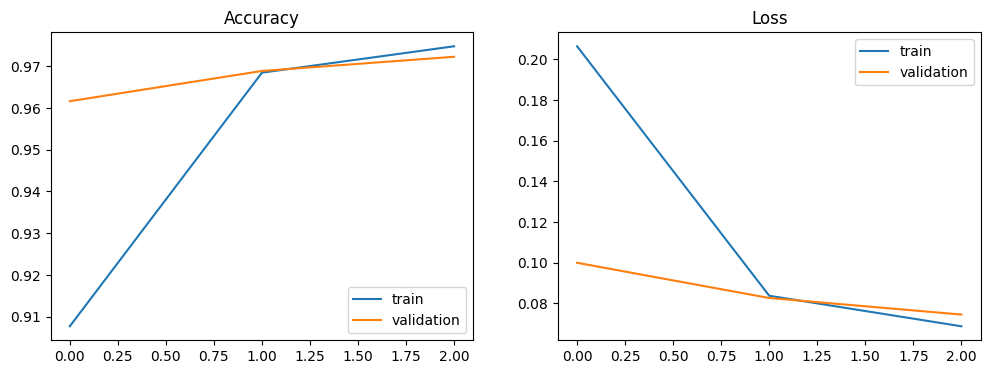

In [16]:
cnn_4block = vgg_dropout(blocks=4)
cnn_4block.summary()

cnn_4block.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_4block = cnn_4block.fit(
    train_generator,
    epochs=3,
    verbose=1,
    validation_data=test_generator,
    callbacks=[reduce_lr],
)

plot_results(history_4block)

### 4.2 Default vs Higher Initial Learning Rate

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,172,194 (8.29 MB)

 Trainable params: 2,172,194 (8.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 133s 213ms/step - accuracy: 0.5828 - loss: 0.7822 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 0.0050
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5839 - loss: 0.6792
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
594/594 ━━━━━━━━━━━━━━━━━━━━ 123s 207ms/step - accuracy: 0.5831 - loss: 0.6795 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 0.0050
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 208ms/step - accuracy: 0.5831 - loss: 0.6794 - val_accuracy: 0.5838 - val_loss: 0.6790 - learning_rate: 0.0025
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5830 - loss: 0.6794
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.
594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step - accuracy: 0.5831 - loss: 0.6794 - val_accuracy: 0.5838 - val_loss: 0.6790 - learning_rate: 0.0025
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 208ms/step - accuracy: 0.

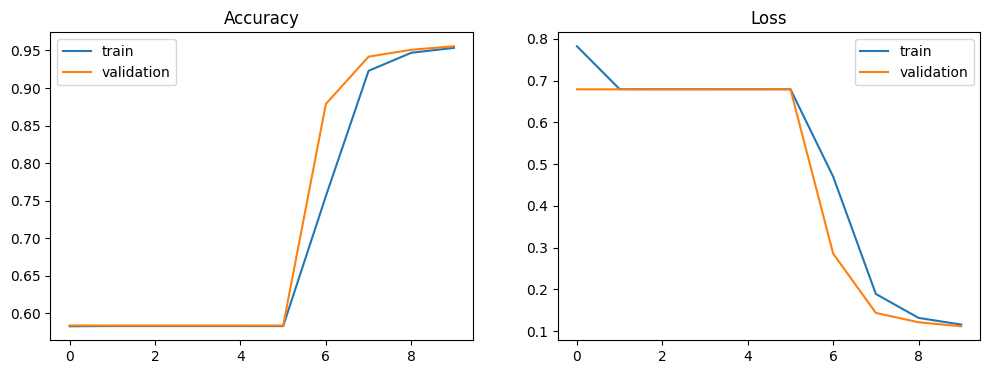

In [17]:
cnn_4block_lr = vgg_dropout(blocks=4)
cnn_4block_lr.summary()

cnn_4block_lr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_4block_lr = cnn_4block_lr.fit(
    train_generator,
    epochs=10,
    verbose=1,
    validation_data=test_generator,
    callbacks=[reduce_lr],
)

plot_results(history_4block_lr)

### 4.3 Four Blocks vs Five Blocks

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 6, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 6, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           25

 Total params: 5,122,338 (19.54 MB)

 Trainable params: 5,122,338 (19.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 139s 220ms/step - accuracy: 0.7427 - loss: 0.4601 - val_accuracy: 0.9481 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9546 - loss: 0.1199
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 206ms/step - accuracy: 0.9578 - loss: 0.1101 - val_accuracy: 0.9612 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 208ms/step - accuracy: 0.9698 - loss: 0.0806 - val_accuracy: 0.9688 - val_loss: 0.0821 - learning_rate: 5.0000e-04
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 209ms/step - accuracy: 0.9739 - loss: 0.0709 - val_accuracy: 0.9726 - val_loss: 0.0732 - learning_rate: 5.0000e-04
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 201ms/step - accuracy: 0.9765 - loss: 0.0646 - val_accuracy: 0.9731 - val_loss: 0.0720 - learning_rate: 5.0000e-04
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step

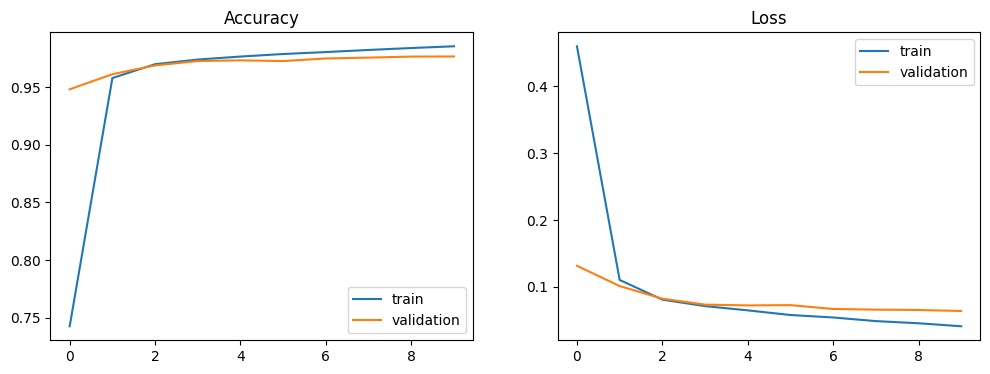

In [18]:
cnn_5block = vgg_dropout(blocks=5)
cnn_5block.summary()

cnn_5block.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_5block = cnn_5block.fit(
    train_generator,
    epochs=10,
    verbose=1,
    validation_data=test_generator,
    callbacks=[reduce_lr],
)

plot_results(history_5block)

## 5. Batch-Size Comparison


Batch size: 64
Found 151949 validated image filenames belonging to 2 classes.
Found 50650 validated image filenames belonging to 2 classes.
Epoch 1/10
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 150s 57ms/step - accuracy: 0.5830 - loss: 0.6801 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 2/10
2374/2375 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5845 - loss: 0.6790
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 126s 53ms/step - accuracy: 0.5831 - loss: 0.6794 - val_accuracy: 0.5838 - val_loss: 0.6794 - learning_rate: 0.0010
Epoch 3/10
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 122s 52ms/step - accuracy: 0.5831 - loss: 0.6794 - val_accuracy: 0.5838 - val_loss: 0.6790 - learning_rate: 5.0000e-04
Epoch 4/10
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 124s 52ms/step - accuracy: 0.5831 - loss: 0.6793 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 5.0000e-04
Epoch 5/10
2375/2375 ━━━━━━━━━━━━━━━━━━━━ 126s 53ms/step - accuracy: 

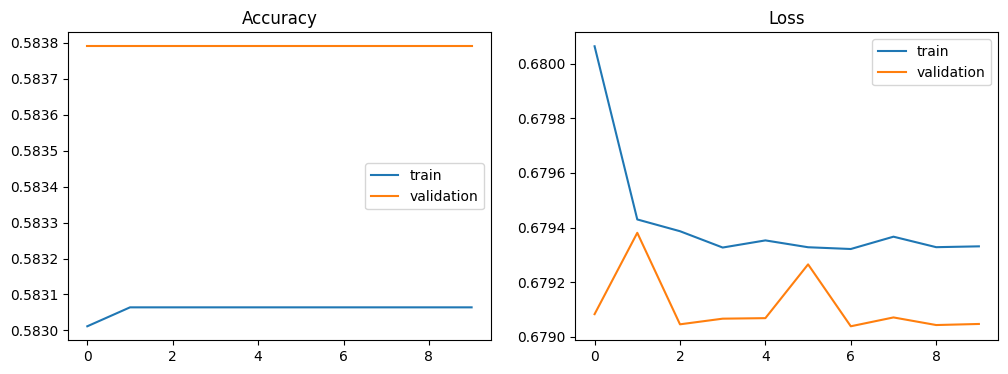


Batch size: 128
Found 151949 validated image filenames belonging to 2 classes.
Found 50650 validated image filenames belonging to 2 classes.
Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 152s 115ms/step - accuracy: 0.5830 - loss: 0.6796 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5810 - loss: 0.6807
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 126s 106ms/step - accuracy: 0.5828 - loss: 0.6799 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 127s 107ms/step - accuracy: 0.5831 - loss: 0.6794 - val_accuracy: 0.5838 - val_loss: 0.6790 - learning_rate: 5.0000e-04
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 124s 104ms/step - accuracy: 0.5831 - loss: 0.6793 - val_accuracy: 0.5838 - val_loss: 0.6791 - learning_rate: 5.0000e-04
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 125s 105ms/step - accuracy:

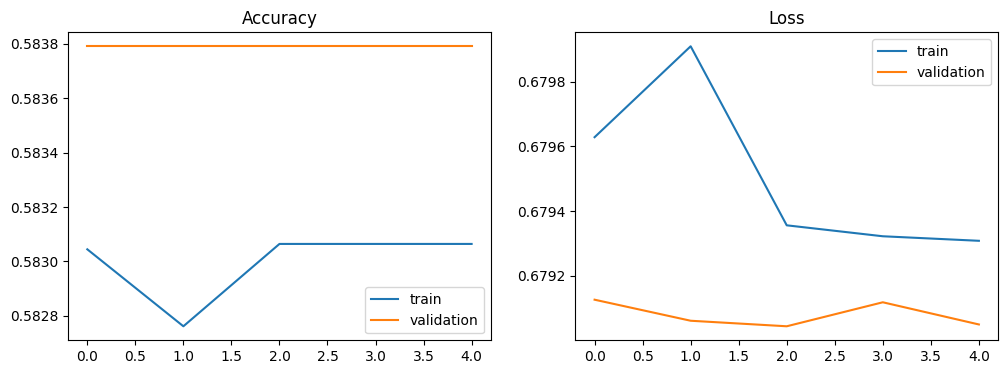


Batch size: 512
Found 151949 validated image filenames belonging to 2 classes.
Found 50650 validated image filenames belonging to 2 classes.
Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 182s 531ms/step - accuracy: 0.8653 - loss: 0.2809 - val_accuracy: 0.9563 - val_loss: 0.1118 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.9604 - loss: 0.1032
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
297/297 ━━━━━━━━━━━━━━━━━━━━ 129s 436ms/step - accuracy: 0.9629 - loss: 0.0979 - val_accuracy: 0.9660 - val_loss: 0.0886 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 135s 456ms/step - accuracy: 0.9741 - loss: 0.0692 - val_accuracy: 0.9725 - val_loss: 0.0720 - learning_rate: 5.0000e-04
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 127s 428ms/step - accuracy: 0.9773 - loss: 0.0611 - val_accuracy: 0.9747 - val_loss: 0.0664 - learning_rate: 5.0000e-04
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 128s 430ms/step - accuracy: 0.980

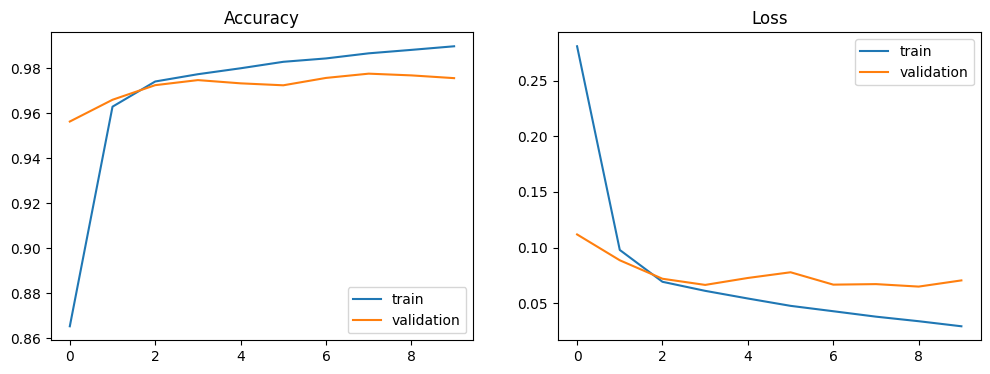

In [19]:
for batch_size, epochs in [(64, 10), (128, 5), (512, 10)]:
    print("\nBatch size:", batch_size)

    train_gen_batch = basic_datagen.flow_from_dataframe(
        train_binary,
        x_col="filename",
        y_col="class",
        target_size=(109, 89),
        directory=str(IMAGE_DIR),
        batch_size=batch_size,
    )

    test_gen_batch = basic_datagen.flow_from_dataframe(
        test_binary,
        x_col="filename",
        y_col="class",
        target_size=(109, 89),
        directory=str(IMAGE_DIR),
        batch_size=batch_size,
        shuffle=False,
    )

    model = vgg_dropout(blocks=5)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_gen_batch,
        epochs=epochs,
        verbose=1,
        validation_data=test_gen_batch,
        callbacks=[reduce_lr],
    )

    plot_results(history)

## 6. Max Pooling vs Average Pooling and Batch Normalization

In [20]:
def vgg_average_pooling(
    input_shape=(109, 89, 3),
    blocks=3,
    branching_factor=2,
    first_layer_filters=32,
    dropout=0.0,
    dense_layer=128,
    use_batch_norm=False,
):
    model = Sequential([Input(shape=input_shape)])

    filters = first_layer_filters

    for _ in range(blocks):
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(AveragePooling2D((2, 2)))

        if use_batch_norm:
            model.add(BatchNormalization())

        model.add(Dropout(dropout))

        filters = int(filters * branching_factor)

    model.add(Flatten())

    if dense_layer > 0:
        model.add(Dense(dense_layer, activation="relu"))
        model.add(Dense(dense_layer, activation="relu"))

        if use_batch_norm:
            model.add(BatchNormalization())

        model.add(Dropout(dropout))

    model.add(Dense(2, activation="softmax"))

    return model

### 6.1 Average Pooling Without Batch Normalization

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 54, 44, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 27, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 13, 11, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 6, 5, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 6, 5, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 6, 5, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 3, 2, 512)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 3, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,122,338 (19.54 MB)

 Trainable params: 5,122,338 (19.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 137s 220ms/step - accuracy: 0.7756 - loss: 0.4321 - val_accuracy: 0.9430 - val_loss: 0.1464 - learning_rate: 0.0010
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9471 - loss: 0.1318
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 128s 216ms/step - accuracy: 0.9532 - loss: 0.1193 - val_accuracy: 0.9620 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step - accuracy: 0.9686 - loss: 0.0833 - val_accuracy: 0.9680 - val_loss: 0.0819 - learning_rate: 5.0000e-04
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 206ms/step - accuracy: 0.9727 - loss: 0.0724 - val_accuracy: 0.9716 - val_loss: 0.0747 - learning_rate: 5.0000e-04
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 121s 203ms/step - accuracy: 0.9758 - loss: 0.0643 - val_accuracy: 0.9727 - val_loss: 0.0726 - learning_rate: 5.0000e-04
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 211ms/step

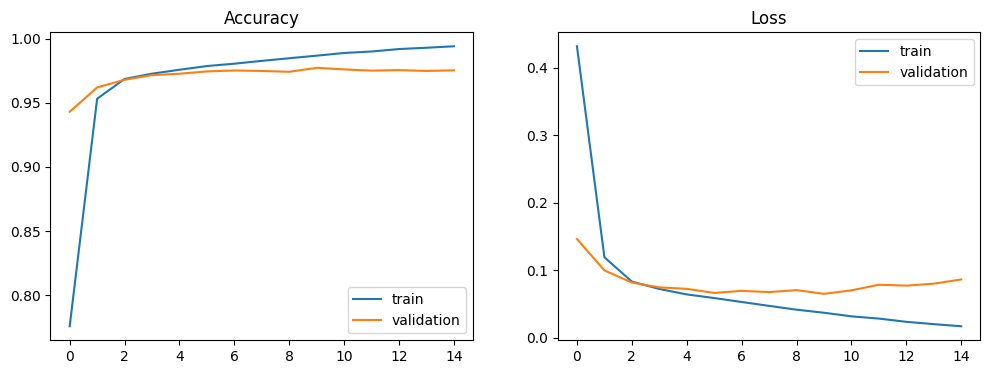

In [21]:
avg_5_no_bn = vgg_average_pooling(
    blocks=5,
    use_batch_norm=False,
)

avg_5_no_bn.summary()

avg_5_no_bn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_avg_5_no_bn = avg_5_no_bn.fit(
    train_generator,
    epochs=15,
    verbose=1,
    validation_data=test_generator,
    callbacks=[reduce_lr],
)

plot_results(history_avg_5_no_bn)

### 6.2 Average Pooling With Batch Normalization


Average pooling + batch normalization, blocks = 4


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_66 (Conv2D)              │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 54, 44, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 27, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 13, 11, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 13, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_8             │ (None, 6, 5, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 7680)           │             

 Total params: 2,174,626 (8.30 MB)

 Trainable params: 2,173,410 (8.29 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 138s 217ms/step - accuracy: 0.9418 - loss: 0.1440 - val_accuracy: 0.9669 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 2/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9734 - loss: 0.0721
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 120s 202ms/step - accuracy: 0.9733 - loss: 0.0715 - val_accuracy: 0.9578 - val_loss: 0.1101 - learning_rate: 0.0010
Epoch 3/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 206ms/step - accuracy: 0.9823 - loss: 0.0492 - val_accuracy: 0.9772 - val_loss: 0.0620 - learning_rate: 5.0000e-04
Epoch 4/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 123s 207ms/step - accuracy: 0.9846 - loss: 0.0435 - val_accuracy: 0.9743 - val_loss: 0.0692 - learning_rate: 5.0000e-04
Epoch 5/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 123s 207ms/step - accuracy: 0.9868 - loss: 0.0371 - val_accuracy: 0.9791 - val_loss: 0.0585 - learning_rate: 5.0000e-04
Epoch 6/10
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 210ms/step

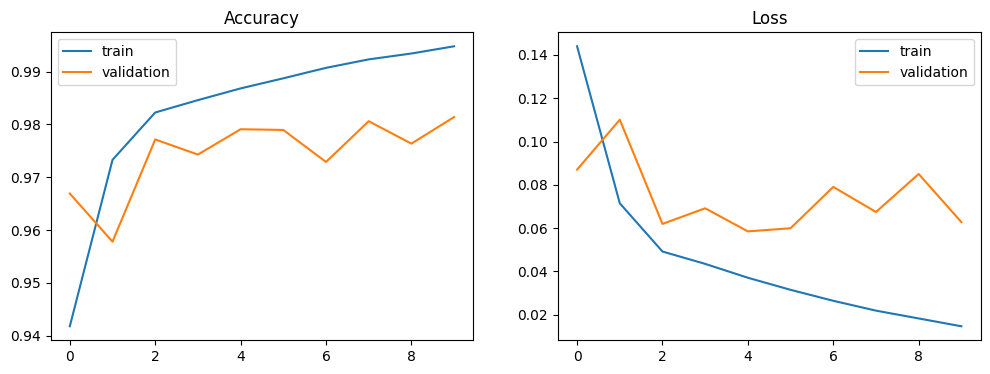


Average pooling + batch normalization, blocks = 5


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_74 (Conv2D)              │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ (None, 54, 44, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 54, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 27, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 27, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 13, 11, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 13, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 6, 5, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 6, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 6, 5, 512)      │     1,180,16

 Total params: 5,126,818 (19.56 MB)

 Trainable params: 5,124,578 (19.55 MB)

 Non-trainable params: 2,240 (8.75 KB)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 147s 229ms/step - accuracy: 0.9130 - loss: 0.2009 - val_accuracy: 0.9189 - val_loss: 0.1834 - learning_rate: 0.0010
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9670 - loss: 0.0856
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 126s 212ms/step - accuracy: 0.9693 - loss: 0.0814 - val_accuracy: 0.9655 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 119s 200ms/step - accuracy: 0.9798 - loss: 0.0551 - val_accuracy: 0.9776 - val_loss: 0.0609 - learning_rate: 5.0000e-04
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 128s 216ms/step - accuracy: 0.9822 - loss: 0.0486 - val_accuracy: 0.9777 - val_loss: 0.0613 - learning_rate: 5.0000e-04
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 124s 208ms/step - accuracy: 0.9845 - loss: 0.0432 - val_accuracy: 0.9770 - val_loss: 0.0617 - learning_rate: 5.0000e-04
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 122s 206ms/step

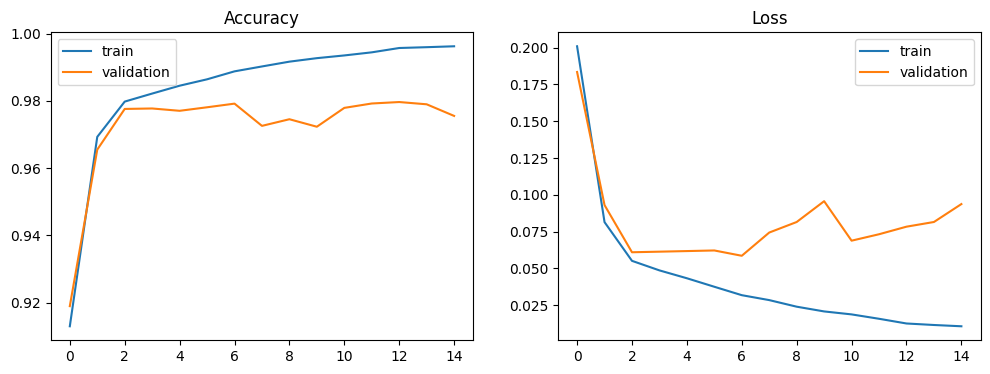

In [22]:
for blocks, epochs in [(4, 10), (5, 15)]:
    print("\nAverage pooling + batch normalization, blocks =", blocks)

    model = vgg_average_pooling(
        blocks=blocks,
        use_batch_norm=True,
    )

    model.summary()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_generator,
        epochs=epochs,
        verbose=1,
        validation_data=test_generator,
        callbacks=[reduce_lr],
    )

    plot_results(history)

### 6.3 Four-Block Architecture: With vs Without Batch Normalization

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_84 (Conv2D)              │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_14            │ (None, 54, 44, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_15            │ (None, 27, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_16            │ (None, 13, 11, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_17            │ (None, 6, 5, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       983,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,172,194 (8.29 MB)

 Trainable params: 2,172,194 (8.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 136s 219ms/step - accuracy: 0.8708 - loss: 0.2688 - val_accuracy: 0.9576 - val_loss: 0.1082 - learning_rate: 0.0010
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9599 - loss: 0.1022
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 210ms/step - accuracy: 0.9626 - loss: 0.0970 - val_accuracy: 0.9677 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 128s 215ms/step - accuracy: 0.9742 - loss: 0.0695 - val_accuracy: 0.9724 - val_loss: 0.0728 - learning_rate: 5.0000e-04
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 123s 207ms/step - accuracy: 0.9775 - loss: 0.0610 - val_accuracy: 0.9756 - val_loss: 0.0655 - learning_rate: 5.0000e-04
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 129s 217ms/step - accuracy: 0.9800 - loss: 0.0550 - val_accuracy: 0.9757 - val_loss: 0.0643 - learning_rate: 5.0000e-04
Epoch 6/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 125s 210ms/step

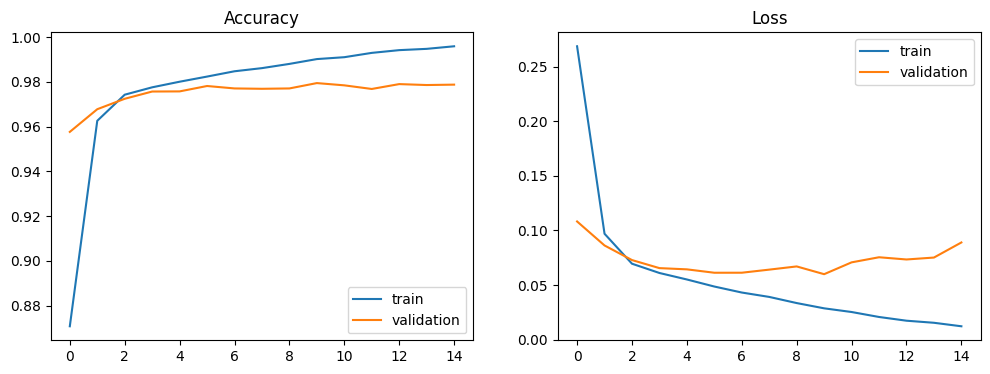

In [23]:
avg_4_no_bn = vgg_average_pooling(
    blocks=4,
    use_batch_norm=False,
)

avg_4_no_bn.summary()

avg_4_no_bn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_avg_4_no_bn = avg_4_no_bn.fit(
    train_generator,
    epochs=15,
    verbose=1,
    validation_data=test_generator,
    callbacks=[reduce_lr],
)

plot_results(history_avg_4_no_bn)

## 7. Without vs With Image Augmentation

In [24]:
train_datagen_aug = ImageDataGenerator(
    rotation_range=20,
    rescale=1.0 / 255.0,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen_aug = ImageDataGenerator(
    rescale=1.0 / 255.0,
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_binary,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
)

test_generator_aug = test_datagen_aug.flow_from_dataframe(
    test_binary,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    shuffle=False,
)

Found 151949 validated image filenames belonging to 2 classes.
Found 50650 validated image filenames belonging to 2 classes.



Augmented average-pooling network, blocks = 4
Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 467s 772ms/step - accuracy: 0.8707 - loss: 0.2836 - val_accuracy: 0.9236 - val_loss: 0.1903 - learning_rate: 0.0010
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.9504 - loss: 0.1225
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 451s 758ms/step - accuracy: 0.9555 - loss: 0.1125 - val_accuracy: 0.9664 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 448s 755ms/step - accuracy: 0.9688 - loss: 0.0820 - val_accuracy: 0.9741 - val_loss: 0.0687 - learning_rate: 5.0000e-04
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 454s 765ms/step - accuracy: 0.9721 - loss: 0.0742 - val_accuracy: 0.9759 - val_loss: 0.0635 - learning_rate: 5.0000e-04
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 452s 761ms/step - accuracy: 0.9737 - loss: 0.0695 - val_accuracy: 0.9708 - val_loss: 0.0743 - learning_rate: 5.0000e-04
Epoch 6/

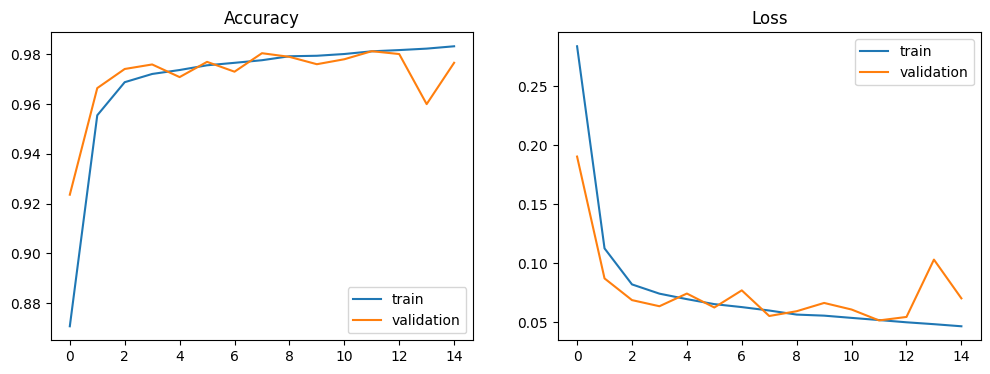


Augmented average-pooling network, blocks = 5
Epoch 1/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 466s 766ms/step - accuracy: 0.8738 - loss: 0.2777 - val_accuracy: 0.7228 - val_loss: 0.8608 - learning_rate: 0.0010
Epoch 2/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.9527 - loss: 0.1191
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 452s 760ms/step - accuracy: 0.9564 - loss: 0.1105 - val_accuracy: 0.9506 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 3/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 445s 749ms/step - accuracy: 0.9700 - loss: 0.0782 - val_accuracy: 0.9777 - val_loss: 0.0604 - learning_rate: 5.0000e-04
Epoch 4/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 445s 749ms/step - accuracy: 0.9729 - loss: 0.0714 - val_accuracy: 0.9753 - val_loss: 0.0656 - learning_rate: 5.0000e-04
Epoch 5/15
594/594 ━━━━━━━━━━━━━━━━━━━━ 445s 749ms/step - accuracy: 0.9746 - loss: 0.0678 - val_accuracy: 0.9709 - val_loss: 0.0772 - learning_rate: 5.0000e-04
Epoch 6/

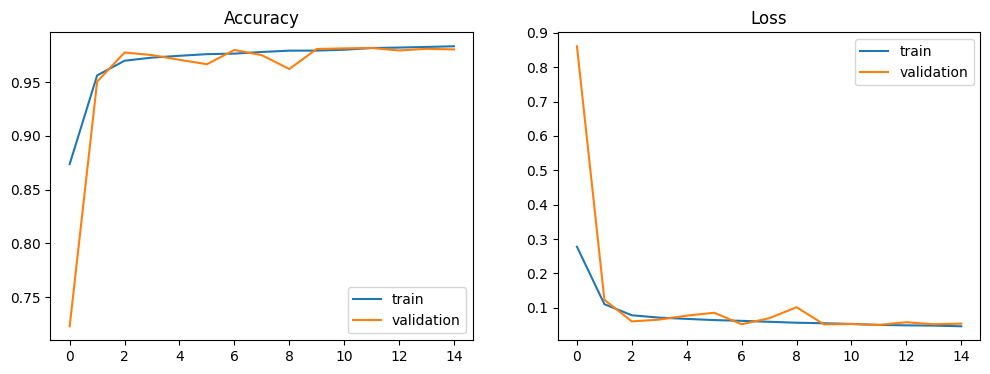

In [25]:
for blocks in [4, 5]:
    print("\nAugmented average-pooling network, blocks =", blocks)

    model = vgg_average_pooling(
        blocks=blocks,
        use_batch_norm=True,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_generator_aug,
        epochs=15,
        verbose=1,
        validation_data=test_generator_aug,
        callbacks=[reduce_lr],
    )

    plot_results(history)

## 8. Sequential vs Functional API Formulation

In [27]:
df_functional = pd.read_excel(BINARY_LABEL_FILE)
df_functional = df_functional.replace({"Female": 0, "Male": 1})
df_functional = shuffle(df_functional, random_state=42)

train_functional, test_functional = train_test_split(
    df_functional,
    test_size=0.25,
    random_state=42,
)

train_generator_raw = train_datagen_aug.flow_from_dataframe(
    train_functional,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
)

test_generator_raw = test_datagen_aug.flow_from_dataframe(
    test_functional,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
    shuffle=False,
)

NameError: name 'BINARY_LABEL_FILE' is not defined

In [ ]:
"""
def functional_vgg4_binary(
    input_shape=(109, 89, 3),
    dropout_rate=0.2,
):
    inputs = Input(shape=input_shape)
    x = inputs

    for filters in (32, 64, 128, 256):
        x = Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = MaxPooling2D((2, 2))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)

    outputs = Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs)


binary_model = functional_vgg4_binary()
binary_model.summary()

binary_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

history_binary = binary_model.fit(
    train_generator_raw,
    epochs=15,
    verbose=1,
    validation_data=test_generator_raw,
    callbacks=[reduce_lr],
)

plot_results(
    history_binary,
    accuracy_key="binary_accuracy",
    val_accuracy_key="val_binary_accuracy",
)
"""

In [28]:
df_functional = df_binary.copy()

df_functional["class"] = df_functional["class"].replace(
    {
        "Female": 0,
        "Male": 1
    }
)

df_functional = shuffle(
    df_functional,
    random_state=42
)

train_functional, test_functional = train_test_split(
    df_functional,
    test_size=0.25,
    random_state=42,
    stratify=df_functional["class"]
)

train_generator_raw = train_datagen_aug.flow_from_dataframe(
    train_functional,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw"
)

test_generator_raw = test_datagen_aug.flow_from_dataframe(
    test_functional,
    x_col="filename",
    y_col="class",
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
    shuffle=False
)

/tmp/ipykernel_8570/242958627.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_functional["class"] = df_functional["class"].replace(


Found 151949 validated image filenames.
Found 50650 validated image filenames.


## 9. Multi-Attribute Output and Objective Comparison

CelebA contains 40 binary attributes. The following sections preserve several target/objective formulations to show why multi-label prediction requires different output and loss choices from single-label classification.

### 9.1 80-Target One-Hot Encoding + Softmax

In [30]:
df_multi_80 = pd.read_csv(ATTRIBUTE_FILE)

filenames = df_multi_80[["image_id"]]

attributes = df_multi_80.drop(
    columns="image_id"
)

attributes = attributes.replace(
    {
        -1: "No",
        1: "Yes"
    }
)

attributes = pd.get_dummies(
    attributes
)

df_multi_80 = pd.concat(
    [filenames, attributes],
    axis=1
)

df_multi_80 = df_multi_80.rename(
    columns={
        "image_id": "filename"
    }
)

print(
    "Number of target columns:",
    len(df_multi_80.columns) - 1
)

display(
    df_multi_80.head()
)

Number of target columns: 80


,filename,5_o_Clock_Shadow_No,5_o_Clock_Shadow_Yes,Arched_Eyebrows_No,Arched_Eyebrows_Yes,Attractive_No,Attractive_Yes,Bags_Under_Eyes_No,Bags_Under_Eyes_Yes,Bald_No,...,Wearing_Hat_No,Wearing_Hat_Yes,Wearing_Lipstick_No,Wearing_Lipstick_Yes,Wearing_Necklace_No,Wearing_Necklace_Yes,Wearing_Necktie_No,Wearing_Necktie_Yes,Young_No,Young_Yes
0,000001.jpg,True,False,False,True,False,True,True,False,True,...,True,False,False,True,True,False,True,False,False,True
1,000002.jpg,True,False,True,False,True,False,False,True,True,...,True,False,True,False,True,False,True,False,False,True
2,000003.jpg,True,False,True,False,True,False,True,False,True,...,True,False,True,False,True,False,True,False,False,True
3,000004.jpg,True,False,True,False,False,True,True,False,True,...,True,False,False,True,False,True,True,False,False,True
4,000005.jpg,True,False,False,True,False,True,True,False,True,...,True,False,False,True,True,False,True,False,False,True


In [31]:
df_multi_80 = shuffle(df_multi_80, random_state=42)

train_multi_80, test_multi_80 = train_test_split(
    df_multi_80,
    test_size=0.25,
    random_state=42,
)

target_columns_80 = list(train_multi_80.columns[1:])

train_generator_80 = train_datagen_aug.flow_from_dataframe(
    train_multi_80,
    x_col="filename",
    y_col=target_columns_80,
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
)

test_generator_80 = test_datagen_aug.flow_from_dataframe(
    test_multi_80,
    x_col="filename",
    y_col=target_columns_80,
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
    shuffle=False,
)

Found 151949 validated image filenames.
Found 50650 validated image filenames.


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_110 (Conv2D)             │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_27            │ (None, 54, 44, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 54, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_28            │ (None, 27, 22, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 27, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_29            │ (None, 13, 11, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 13, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_30            │ (None, 6, 5, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 6, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 7680)           │             

 Total params: 2,184,688 (8.33 MB)

 Trainable params: 2,183,472 (8.33 MB)

 Non-trainable params: 1,216 (4.75 KB)

Epoch 1/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 472s 773ms/step - accuracy: 3.1590e-04 - loss: 1471.3298 - val_accuracy: 0.0000e+00 - val_loss: 2912.9504 - learning_rate: 0.0010
Epoch 2/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.0000e+00 - loss: 3474.5512
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 446s 750ms/step - accuracy: 0.0000e+00 - loss: 4190.1973 - val_accuracy: 0.0000e+00 - val_loss: 4883.9443 - learning_rate: 0.0010
Epoch 3/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 450s 758ms/step - accuracy: 0.0000e+00 - loss: 6512.4673 - val_accuracy: 0.0000e+00 - val_loss: 6482.2876 - learning_rate: 5.0000e-04
Epoch 4/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 445s 750ms/step - accuracy: 0.0000e+00 - loss: 8210.6904 - val_accuracy: 3.9487e-05 - val_loss: 10386.4707 - learning_rate: 5.0000e-04
Epoch 5/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 448s 754ms/step - accuracy: 9.2136e-05 - loss: 10049.2939 - val_accuracy: 0.0000e+00 - val_loss: 14571.1182 - l

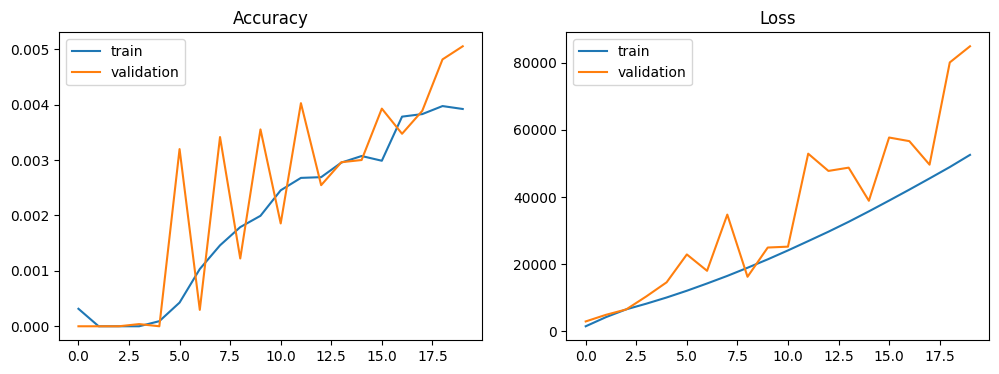

In [32]:
def multi_output_softmax_model(
    output_units,
    input_shape=(109, 89, 3),
    blocks=4,
    dropout=0.0,
):
    model = Sequential([Input(shape=input_shape)])

    filters = 32

    for _ in range(blocks):
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        model.add(AveragePooling2D((2, 2)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
        filters *= 2

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))
    model.add(Dense(output_units, activation="softmax"))

    return model


model_80_accuracy = multi_output_softmax_model(output_units=80)
model_80_accuracy.summary()

model_80_accuracy.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_80_accuracy = model_80_accuracy.fit(
    train_generator_80,
    epochs=20,
    verbose=1,
    validation_data=test_generator_80,
    callbacks=[reduce_lr],
)

plot_results(history_80_accuracy)

### 9.2 Categorical Accuracy vs Binary Accuracy Metric

Epoch 1/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 464s 766ms/step - binary_accuracy: 0.5013 - loss: 1519.1742 - val_binary_accuracy: 0.5041 - val_loss: 2163.2205 - learning_rate: 0.0010
Epoch 2/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - binary_accuracy: 0.5059 - loss: 3571.7841
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 447s 752ms/step - binary_accuracy: 0.5061 - loss: 4321.1875 - val_binary_accuracy: 0.5065 - val_loss: 6038.8359 - learning_rate: 0.0010
Epoch 3/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 453s 763ms/step - binary_accuracy: 0.5056 - loss: 6838.0098 - val_binary_accuracy: 0.5052 - val_loss: 7933.5308 - learning_rate: 5.0000e-04
Epoch 4/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 443s 746ms/step - binary_accuracy: 0.5053 - loss: 8719.6670 - val_binary_accuracy: 0.5046 - val_loss: 14525.0537 - learning_rate: 5.0000e-04
Epoch 5/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 456s 768ms/step - binary_accuracy: 0.5051 - loss: 10747.6807 - val_binary_accuracy: 

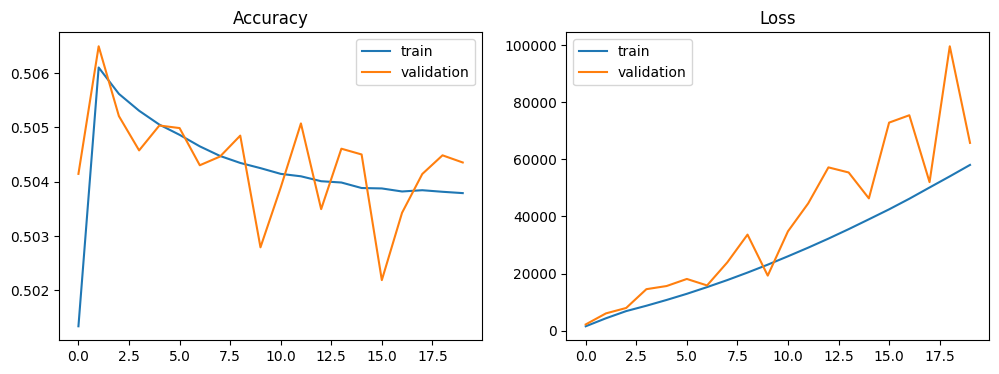

In [33]:
model_80_binary_metric = multi_output_softmax_model(output_units=80)

model_80_binary_metric.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["binary_accuracy"],
)

history_80_binary_metric = model_80_binary_metric.fit(
    train_generator_80,
    epochs=20,
    verbose=1,
    validation_data=test_generator_80,
    callbacks=[reduce_lr],
)

plot_results(
    history_80_binary_metric,
    accuracy_key="binary_accuracy",
    val_accuracy_key="val_binary_accuracy",
)

These experiments illustrate a mismatch: the 40 CelebA attributes are independent binary targets, while a single 80-way softmax treats all outputs as one mutually exclusive distribution.

### 9.3 80-Target vs 40-Target Softmax Formulations

In [38]:
df_multi_40 = pd.read_csv(ATTRIBUTE_FILE)

# Convert CelebA labels from {-1, 1} to {0, 1}
df_multi_40 = df_multi_40.replace({
    -1: 0,
    1: 1
})

# Rename image identifier column
df_multi_40 = df_multi_40.rename(
    columns={
        "image_id": "filename"
    }
)

# Shuffle the dataset
df_multi_40 = shuffle(
    df_multi_40,
    random_state=42
)

# Train-test split
train_multi_40, test_multi_40 = train_test_split(
    df_multi_40,
    test_size=0.25,
    random_state=42
)

# The remaining 40 columns are the target attributes
target_columns_40 = list(
    train_multi_40.columns[1:]
)

print("Number of target attributes:", len(target_columns_40))


# Image generators
train_generator_40 = train_datagen_aug.flow_from_dataframe(
    train_multi_40,
    x_col="filename",
    y_col=target_columns_40,
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw"
)

test_generator_40 = test_datagen_aug.flow_from_dataframe(
    test_multi_40,
    x_col="filename",
    y_col=target_columns_40,
    target_size=(109, 89),
    directory=str(IMAGE_DIR),
    batch_size=256,
    class_mode="raw",
    shuffle=False
)

Number of target attributes: 40
Found 151949 validated image filenames.
Found 50650 validated image filenames.


## 10. Softmax vs Sigmoid for Multi-Label Prediction

In [39]:
def functional_vgg4_multilabel(
    input_shape=(109, 89, 3),
    dropout_rate=0.2,
    output_units=40,
):
    inputs = Input(shape=input_shape)
    x = inputs

    for filters in (32, 64, 128, 256):
        x = Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = Conv2D(filters, (3, 3), padding="same", activation="relu")(x)
        x = MaxPooling2D((2, 2))(x)
        x = BatchNormalization()(x)
        x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    x = Dense(128, activation="relu")(x)

    outputs = Dense(
        output_units,
        activation="sigmoid",
    )(x)

    return Model(inputs, outputs)

### 10.1 Sigmoid + Categorical Cross-Entropy

Model: "functional_355"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 109, 89, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_134 (Conv2D)             │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_135 (Conv2D)             │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 54, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_136 (Conv2D)             │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_137 (Conv2D)             │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 27, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_138 (Conv2D)             │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 13, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_140 (Conv2D)             │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_141 (Conv2D)             │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 6, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │       983,16

 Total params: 2,162,504 (8.25 MB)

 Trainable params: 2,161,544 (8.25 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 480s 782ms/step - binary_accuracy: 0.2285 - loss: 27476.4219 - val_binary_accuracy: 0.2259 - val_loss: 87256.9922 - learning_rate: 0.0010
Epoch 2/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - binary_accuracy: 0.2258 - loss: 118486.6299
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 453s 763ms/step - binary_accuracy: 0.2258 - loss: 165972.7031 - val_binary_accuracy: 0.2259 - val_loss: 286990.5312 - learning_rate: 0.0010
Epoch 3/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 455s 766ms/step - binary_accuracy: 0.2258 - loss: 270731.3438 - val_binary_accuracy: 0.2259 - val_loss: 294596.5625 - learning_rate: 5.0000e-04
Epoch 4/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 451s 758ms/step - binary_accuracy: 0.2258 - loss: 265748.7500 - val_binary_accuracy: 0.2259 - val_loss: 268865.2500 - learning_rate: 5.0000e-04
Epoch 5/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 451s 760ms/step - binary_accuracy: 0.2258 - loss: 256718.4531 - val_b

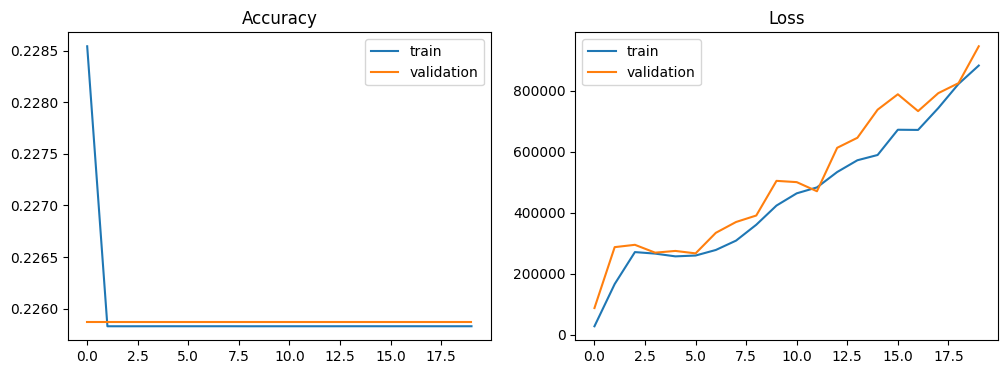

In [40]:
multilabel_categorical = functional_vgg4_multilabel()
multilabel_categorical.summary()

multilabel_categorical.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["binary_accuracy"],
)

history_multilabel_categorical = multilabel_categorical.fit(
    train_generator_40,
    epochs=20,
    verbose=1,
    validation_data=test_generator_40,
    callbacks=[reduce_lr],
)

plot_results(
    history_multilabel_categorical,
    accuracy_key="binary_accuracy",
    val_accuracy_key="val_binary_accuracy",
)

### 10.2 Sigmoid + Binary Cross-Entropy

Model: "functional_356"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 109, 89, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_142 (Conv2D)             │ (None, 109, 89, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_143 (Conv2D)             │ (None, 109, 89, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 54, 44, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_85 (Dropout)            │ (None, 54, 44, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_144 (Conv2D)             │ (None, 54, 44, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_145 (Conv2D)             │ (None, 54, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 27, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_86 (Dropout)            │ (None, 27, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_146 (Conv2D)             │ (None, 27, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_147 (Conv2D)             │ (None, 27, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 13, 11, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_87 (Dropout)            │ (None, 13, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_148 (Conv2D)             │ (None, 13, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_149 (Conv2D)             │ (None, 13, 11, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 6, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 6, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │       983,16

 Total params: 2,162,504 (8.25 MB)

 Trainable params: 2,161,544 (8.25 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 473s 774ms/step - binary_accuracy: 0.8568 - loss: 0.3251 - val_binary_accuracy: 0.8450 - val_loss: 0.3654 - learning_rate: 0.0010
Epoch 2/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - binary_accuracy: 0.8870 - loss: 0.2575
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
594/594 ━━━━━━━━━━━━━━━━━━━━ 450s 758ms/step - binary_accuracy: 0.8899 - loss: 0.2509 - val_binary_accuracy: 0.8858 - val_loss: 0.2552 - learning_rate: 0.0010
Epoch 3/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 449s 755ms/step - binary_accuracy: 0.8980 - loss: 0.2320 - val_binary_accuracy: 0.8952 - val_loss: 0.2350 - learning_rate: 5.0000e-04
Epoch 4/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 453s 762ms/step - binary_accuracy: 0.9003 - loss: 0.2265 - val_binary_accuracy: 0.8927 - val_loss: 0.2394 - learning_rate: 5.0000e-04
Epoch 5/20
594/594 ━━━━━━━━━━━━━━━━━━━━ 451s 760ms/step - binary_accuracy: 0.9021 - loss: 0.2223 - val_binary_accuracy: 0.9011 - val_loss: 0.2232 - lear

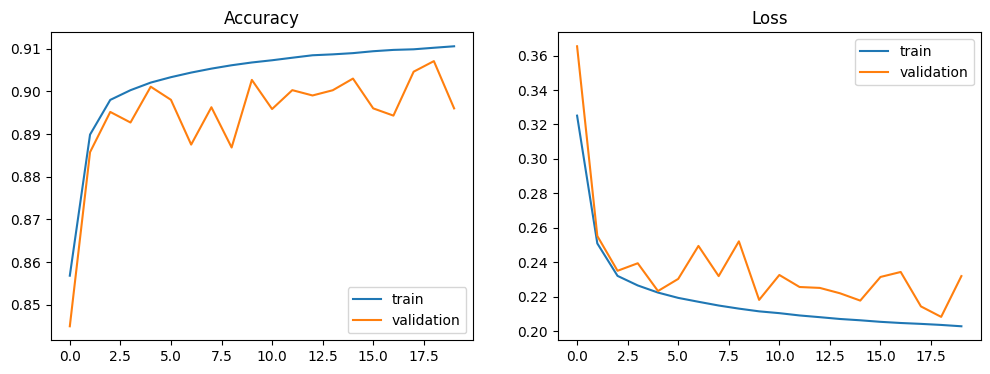

In [41]:
multilabel_bce = functional_vgg4_multilabel()
multilabel_bce.summary()

multilabel_bce.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["binary_accuracy"],
)

history_multilabel_bce = multilabel_bce.fit(
    train_generator_40,
    epochs=20,
    verbose=1,
    validation_data=test_generator_40,
    callbacks=[reduce_lr],
)

plot_results(
    history_multilabel_bce,
    accuracy_key="binary_accuracy",
    val_accuracy_key="val_binary_accuracy",
)

## 11. CelebA Comparison Summary

The final sigmoid + binary cross-entropy formulation matches the structure of CelebA: every image can simultaneously possess many independent attributes. The preceding softmax experiments are useful contrasts because they show how a single-label objective can be inappropriate for multi-label data.

In [42]:
print(tf.test.gpu_device_name())

/device:GPU:0


If the output is an empty string, it means no GPU is detected. If it returns something like `/device:GPU:0`, then a GPU is enabled and available.